In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from tqdm.notebook import tqdm
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r"C:\Users\KIIT\Downloads\parkinson_disease.csv")
pd.set_option('display.max_columns', 10)
df.sample(5)

,id,gender,PPE,DFA,RPDE,...,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
194,64,1,0.76203,0.78088,0.56929,...,12.0455,32.5908,33.8833,90.3304,1
7,2,1,0.83671,0.62079,0.51179,...,5.9610,11.7552,18.0927,5.0448,1
73,24,0,0.83183,0.67400,0.51269,...,2.7531,2.9085,3.1163,2.9546,0
296,98,1,0.81421,0.70452,0.45814,...,17.4721,25.7293,24.6990,65.4766,1
603,201,0,0.80641,0.70794,0.62140,...,3.2759,3.5631,2.8654,3.3151,1


In [5]:
#Data Exploration and Cleaning
#To understand the dataset better we use some built-in functions from the Pandas library. These functions help us inspect the structure, data types and statistical properties of the dataset.
#df.info(): Displays the total number of rows and columns, the data types of each column and the count of non-null values. This helps identify missing data and column types.
#df.describe().T: Provides a transposed statistical summary of numerical columns, including the mean, standard deviation, minimum and maximum values as well as quartiles. This helps us understand the distribution of the data.
#df.isnull().sum().sum(): Checks the total number of missing values in the dataset. If this returns 0 it means there are no missing values. If there are any null/missing values then we start with the data cleaning process to handle those values.
#df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,756.0,125.500000,72.793721,0.000000,62.750000,125.500000,188.250000,251.00000
gender,756.0,0.515873,0.500079,0.000000,0.000000,1.000000,1.000000,1.00000
PPE,756.0,0.746284,0.169294,0.041551,0.762833,0.809655,0.834315,0.90766
DFA,756.0,0.700414,0.069718,0.543500,0.647053,0.700525,0.754985,0.85264
RPDE,756.0,0.489058,0.137442,0.154300,0.386537,0.484355,0.586515,0.87123
...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,756.0,12.375335,16.341665,1.628700,3.114375,4.741450,12.201325,73.53220
tqwt_kurtosisValue_dec_34,756.0,14.799230,15.722502,1.861700,3.665925,6.725700,21.922050,62.00730
tqwt_kurtosisValue_dec_35,756.0,14.751559,14.432979,1.955900,3.741275,7.334250,22.495175,57.54430
tqwt_kurtosisValue_dec_36,756.0,31.481110,34.230991,2.364000,3.948750,10.637250,61.125325,156.42370


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df = df.groupby('id').mean().reset_index()
df.drop('id', axis=1, inplace=True)

In [9]:
columns = list(df.columns)
for col in columns:
    if col == 'class':
        continue
    filtered_columns = [col]
    for col1 in df.columns:
        if((col == col1) | (col == 'class')):
            continue
        val = df[col].corr(df[col1])
        if val > 0.7:
            # If the correlation between the two features is more than 0.7, remove it
            columns.remove(col1)
            continue
        else:
            filtered_columns.append(col1)
    df = df[filtered_columns]
df.shape

(252, 287)

In [10]:
#Feature Selection
#To improve model performance and reduce computational complexity we apply feature selection using the 
#chi-square test to retain only the most relevant features. This helps eliminate redundant or less significant 
#variables making the dataset more efficient for machine learning. Here:
#X = df.drop('class', axis=1): Extracts the feature set by removing the target variable (class).
#MinMaxScaler().fit_transform(X): Normalizes the feature values to a range of [0,1] using Min-Max Scaling. 
#This ensures that all features contribute equally to the model.
#SelectKBest(chi2, k=30): Applies the Chi-Square test to select the 30 most important features based on 
#their relationship with the target variable (class).
#selector.fit(X_norm, df['class']): Fits the feature selection model on the normalized data.
#filtered_columns = selector.get_support(): Identifies the selected features.
#filtered_data = X.loc[:, filtered_columns]: Extracts only the top 30 selected features.
#filtered_data['class'] = df['class']: Reattaches the target variable (class) to the reduced dataset.
X = df.drop('class', axis=1)
X_norm = MinMaxScaler().fit_transform(X)
selector = SelectKBest(chi2, k=30)
selector.fit(X_norm, df['class'])
filtered_columns = selector.get_support()
filtered_data = X.loc[:, filtered_columns]
filtered_data['class'] = df['class']
df = filtered_data
df.shape

(252, 31)

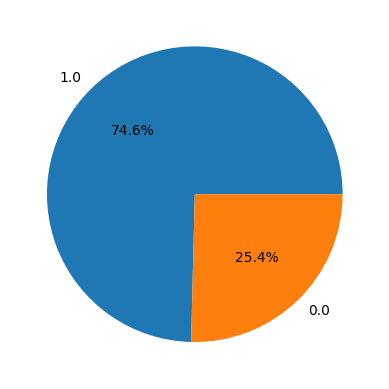

In [11]:
#Handling Class Imbalance and Splitting Data
#To understand the distribution of target classes in our dataset, we use a pie chart. 
#This helps us check for class imbalances, which can impact model performance.
#df['class'].value_counts(): Counts the occurrences of each class in the dataset.
#plt.pie(x.values, labels=x.index, autopct='%1.1f%%'): Creates a pie chart
#x.values: Represents the frequency of each class.#labels=x.index: Assigns class labels to each slice.
#autopct='%1.1f%%': Displays percentages with one decimal place.
#This visualization helps us assess whether the dataset is balanced or 
#imbalanced which is crucial when selecting appropriate evaluation metrics and model strategies
x = df['class'].value_counts()
plt.pie(x.values,
        labels = x.index,
        autopct='%1.1f%%')
plt.show()

In [12]:
#To build a robust machine learning model we need to address this class imbalance and properly split the dataset into training and validation sets. 
#If the dataset is imbalanced the model may become biased toward the majority class making it difficult to correctly predict the minority class. Here: :
#features = df.drop('class', axis=1): Extracts and stores independent variables.
#target = df['class']: Stores the dependent variable.:#train_test_split(features, target, test_size=0.2, random_state=10):
#Allocates 80% of data for training and 20% for validation
#random_state=10 ensures reproducibility.#ros = RandomOverSampler(sampling_strategy='minority', random_state=0): 
#Oversamples the minority class ensuring both classes have equal representation.
#ros.fit_resample(X_train, Y_train): Applies oversampling to the training dataset.
features = df.drop('class', axis=1)
target = df['class'
X_train, X_val,Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.2,
                                      random_state=10)
ros = RandomOverSampler(sampling_strategy=1.0,
                        random_state=0)
X, Y = ros.fit_resample(X_train, Y_train)
X.shape, Y.value_counts()


((302, 30),
 class
 1.0    151
 0.0    151
 Name: count, dtype: int64)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [29]:
features = df.drop('class', axis=1)
target = df['class']

X_train, X_val,Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.2,
                                      random_state=10)

ros = RandomOverSampler(sampling_strategy=1.0,
                        random_state=0)
X, Y = ros.fit_resample(X_train, Y_train)
X.shape, Y.value_counts()

((302, 30),
 class
 1.0    151
 0.0    151
 Name: count, dtype: int64)

In [30]:
#Model Training and Evaluation
#After preparing the dataset, we train multiple machine learning models and 
#evaluate their performance using the ROC AUC Score. This helps us compare 
#different models and choose the best-performing one for our classification task. 
#Here we are using three different classifiers : 
#Logistic Regression, XGBoost Classifier and Support Vector Classifier.
#model.fit(X_resampled, y_resampled: Trains each model in the "models" list .
#model.predict(X_resampled): Predicts outcomes on the training data.
#ras(y_resampled, train_preds): Computes the ROC AUC score for training accuracy.
#model.predict(X_val): Predicts outcomes on the validation dataset.
#ras(y_val, val_preds): Computes the ROC AUC score for validation accuracy.
from sklearn.metrics import roc_auc_score as ras
models = [LogisticRegression(class_weight='balanced'), XGBClassifier(), SVC(kernel='rbf', probability=True)] 
for model in models:
    model.fit(X_resampled, y_resampled)
    print(f'{model} : ')
    train_preds = model.predict(X_resampled)
    print('Training Accuracy : ', ras(y_resampled, train_preds))
    val_preds = model.predict(X_val)
    print('Validation Accuracy : ', ras(y_val, val_preds))
    print()

NameError: name 'X_resampled' is not defined

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(models[0], X_val, y_val, cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

NameError: name 'y_val' is not defined

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities
y_prob = models[0].predict_proba(X_val)[:,1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_val, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(models[0], X_val, y_val)
plt.show()

NameError: name 'y_val' is not defined